In [27]:
import pandas as pd

df = pd.read_csv("exchange_dataset.csv", parse_dates=["date"], index_col="date")
df["usdkrw_lag1"] = df["usdkrw"].shift(1)
df["usdkrw_lag3"] = df["usdkrw"].shift(3)
df["usdkrw_lag5"] = df["usdkrw"].shift(5)

df = df.dropna()
df.head()

,usdkrw,dgs2,dgs10,dfii10,t10yie,vix,stlfsi,dxy,usdkrw_lag1,usdkrw_lag3,usdkrw_lag5
date,,,,,,,,,,,
2021-04-16,1114.93,0.16,1.59,-0.77,2.36,16.25,-0.7649,112.4814,1120.84,1130.38,1124.85
2021-04-23,1115.10,0.16,1.58,-0.76,2.34,17.33,-0.7144,112.0889,1114.93,1129.26,1133.09
2021-04-30,1115.58,0.16,1.65,-0.76,2.41,18.61,-0.8009,112.0839,1115.10,1120.84,1130.38
2021-05-07,1121.06,0.14,1.60,-0.89,2.49,16.69,-0.8026,111.0249,1115.58,1114.93,1129.26
2021-05-14,1126.76,0.16,1.63,-0.88,2.51,18.81,-0.7423,111.1353,1121.06,1115.10,1120.84


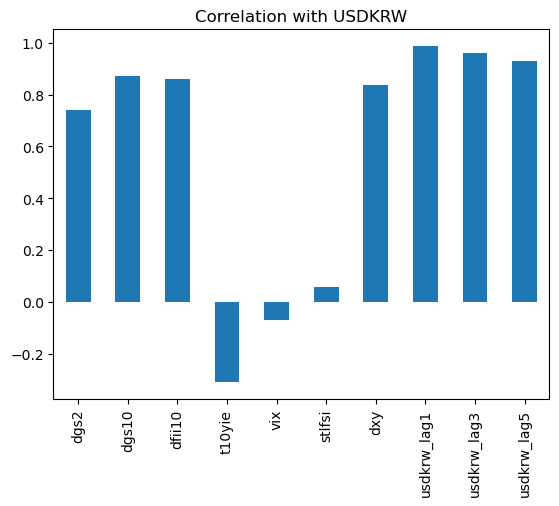

In [28]:
# 환율과의 상관관계
import matplotlib.pyplot as plt

df.corr()["usdkrw"].drop("usdkrw").plot(kind="bar")
plt.title("Correlation with USDKRW")
plt.show()
# df.corr()["usdkrw"].sort_values(ascending=False)

In [29]:
X = df.drop(columns=["usdkrw"])
y = df["usdkrw"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [32]:
model.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9750543638524454


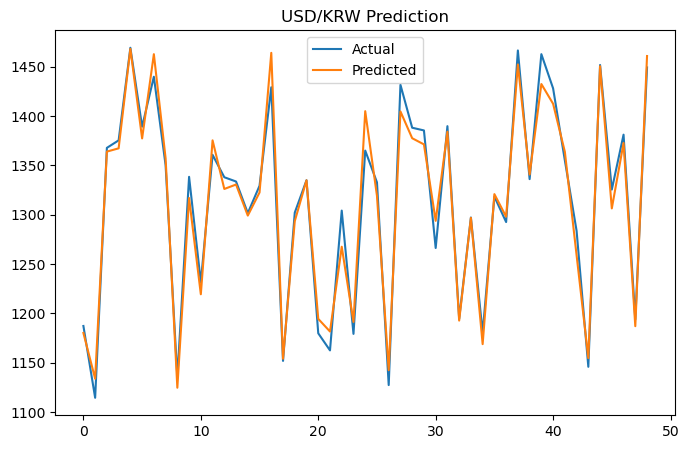

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("USD/KRW Prediction")
plt.show()